In [ ]:
#this is 1d CNN with CONV1D+ temporal pooling

In [ ]:
#We cannot make CNN huge because:

# It runs every 2 seconds

# It is always active

# Best structure:

# 3 Conv1D layers

# Residual connection

# BatchNorm

# GELU activation

# 128–256 embedding

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from sklearn.utils.class_weight import compute_class_weight

In [2]:
#loading Data

X = np.load("X.npy")
y = np.load("y.npy")

print("X shape:", X.shape)   # (samples, features, window)
print("y shape:", y.shape)


X shape: (247830, 2, 9)
y shape: (247830,)


In [3]:
#spliting dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (198264, 2, 9)
Test: (49566, 2, 9)


In [4]:
#Using standard scaler(z-scaler ) for standardization
#as some feature eg:packe in rate may be ver high differences

scaler = StandardScaler()

# reshape to 2D: (samples * timesteps, features)
X_train_flat = X_train.reshape(-1, X_train.shape[2])  # (15996*2, 20)
X_test_flat  = X_test.reshape(-1, X_test.shape[2])

# fit ONLY on training
scaler.fit(X_train_flat)

# transform
X_train_scaled = scaler.transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)

# reshape back to (samples, timesteps, features)
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled  = X_test_scaled.reshape(X_test.shape)

# save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaling complete.")


Scaling complete.


In [5]:
#convert to pytorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).to(device)

print("Device:", device)
#o/p should be cuda for gpu training

Device: cuda


In [6]:
#Dataloader
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [7]:
#defining CNN now 

In [31]:
class SDN_CNN(nn.Module):
    def __init__(self, num_features, num_classes, embedding_dim=128):
        super(SDN_CNN, self).__init__()
        
        self.conv1 = nn.Conv1d(num_features, 64, kernel_size=2)
        self.bn1 = nn.BatchNorm1d(64)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=1)
        self.bn2 = nn.BatchNorm1d(128)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.embedding_layer = nn.Linear(128, embedding_dim)
        
        self.classifier = nn.Linear(embedding_dim, num_classes)
        self.binary_head = nn.Linear(embedding_dim, 1)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        
        x = self.global_pool(x).squeeze(-1)
        
        embedding = self.embedding_layer(x)
        
        multi_logits = self.classifier(embedding)
        binary_logits = self.binary_head(embedding)
        
        return binary_logits, multi_logits, embedding


In [32]:
#model initialization
num_features = X_train_tensor.shape[1]
num_classes = len(np.unique(y))

model = SDN_CNN(num_features, num_classes).to(device)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion_multi = nn.CrossEntropyLoss(weight=class_weights)
criterion_binary = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [35]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        binary_logits, multi_logits, embedding = model(inputs)

        _, preds = torch.max(multi_logits, 1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        
outputs = model(inputs)

multi_logits = outputs[1]   # NOT outputs[0]
_, preds = torch.max(multi_logits, 1)

In [36]:
#training now below

epochs = 12


for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    
    for inputs, labels in train_loader:
        
        optimizer.zero_grad()
        
        binary_logits, multi_logits, _ = model(inputs)
        
        binary_labels = (labels > 0).float().unsqueeze(1)
        
        loss_multi = criterion_multi(multi_logits, labels)
        loss_binary = criterion_binary(binary_logits, binary_labels)
        
        loss = loss_multi + loss_binary
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            _, multi_logits, _ = model(inputs)
            preds = torch.argmax(multi_logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    
    print(
    f"Epoch [{epoch+1:02d}/{epochs}] | "
    f"Loss: {total_loss/len(train_loader):.4f} | "
    f"Acc: {acc:.4f} | "
    f"Prec: {precision_score(all_labels, all_preds, average='macro'):.4f} | "
    f"Rec: {recall_score(all_labels, all_preds, average='macro'):.4f} | "
    f"F1: {f1:.4f}"
)




Epoch [01/12] | Loss: 0.8885 | Acc: 0.8844 | Prec: 0.6728 | Rec: 0.7517 | F1: 0.6754
Epoch [02/12] | Loss: 0.7354 | Acc: 0.8713 | Prec: 0.6730 | Rec: 0.7742 | F1: 0.6644
Epoch [03/12] | Loss: 0.6915 | Acc: 0.8097 | Prec: 0.6648 | Rec: 0.7789 | F1: 0.5979
Epoch [04/12] | Loss: 0.6686 | Acc: 0.9074 | Prec: 0.7067 | Rec: 0.7829 | F1: 0.7027
Epoch [05/12] | Loss: 0.6454 | Acc: 0.9053 | Prec: 0.6942 | Rec: 0.7822 | F1: 0.7051
Epoch [06/12] | Loss: 0.6297 | Acc: 0.8772 | Prec: 0.6986 | Rec: 0.8117 | F1: 0.6738
Epoch [07/12] | Loss: 0.6174 | Acc: 0.8660 | Prec: 0.7007 | Rec: 0.8134 | F1: 0.6602
Epoch [08/12] | Loss: 0.6085 | Acc: 0.9175 | Prec: 0.7045 | Rec: 0.7693 | F1: 0.7089
Epoch [09/12] | Loss: 0.5963 | Acc: 0.8887 | Prec: 0.6954 | Rec: 0.8202 | F1: 0.6900
Epoch [10/12] | Loss: 0.5912 | Acc: 0.8556 | Prec: 0.6974 | Rec: 0.8075 | F1: 0.6474
Epoch [11/12] | Loss: 0.5811 | Acc: 0.9224 | Prec: 0.7048 | Rec: 0.7736 | F1: 0.7199
Epoch [12/12] | Loss: 0.5808 | Acc: 0.9050 | Prec: 0.7102 | Rec: 

In [11]:
for param in model.parameters():
    param.requires_grad = False

model.eval()


SDN_CNN(
  (conv1): Conv1d(2, 64, kernel_size=(2,), stride=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (embedding_layer): Linear(in_features=128, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=3, bias=True)
  (binary_head): Linear(in_features=128, out_features=1, bias=True)
)

In [12]:
#saving modal
torch.save(model.state_dict(), "cnn_model.pth")
print("Modal saved sucessfully")

Modal saved sucessfully



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     13852
           1       0.98      0.99      0.99     34486
           2       0.20      0.73      0.32      1228

    accuracy                           0.91     49566
   macro avg       0.71      0.81      0.70     49566
weighted avg       0.95      0.91      0.92     49566



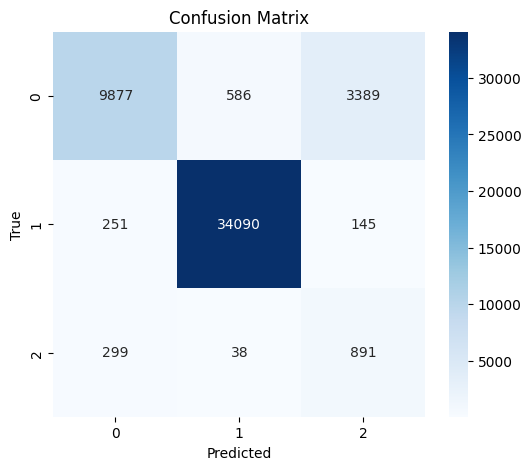

In [37]:
#for confusion matrix to check class discrimination

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        _, multi_logits, _ = model(inputs)
        preds = torch.argmax(multi_logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [24]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        logits = outputs[0]   # ALWAYS take first element as logits
        _, preds = torch.max(logits, 1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

y_pred = all_preds
y_test = all_true

In [38]:
outputs = model(inputs)
print(outputs[0].shape)

torch.Size([158, 1])


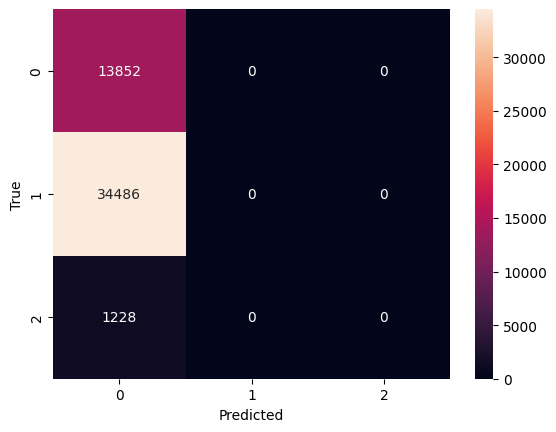

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [41]:
#to check if modal has learned anything or not
print(torch.mean(multi_logits, dim=0))

tensor([ 0.5878,  0.2711, -1.0226], device='cuda:0')
